# Figure 1 K-M: Freely moving augmented reality, system and performance

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env_aws.py
%run run.py connect

2025-07-01 16:32:39,207::INFO::settings.py::Setting loglevel to INFO
2025-07-01 16:32:39,208::INFO::settings.py::Setting stores to {}
2025-07-01 16:32:39,209::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-07-01 16:32:39,210::INFO::settings.py::Setting database.misc.create_tables to True
2025-07-01 16:32:39,211::INFO::settings.py::Setting enable_python_native_blobs to True
2025-07-01 16:32:39,212::INFO::settings.py::Setting database.host to vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com
2025-07-01 16:32:39,214::INFO::settings.py::Setting database.user to celia
2025-07-01 16:32:39,215::INFO::settings.py::Setting database.password to celia_mathislab


Connecting celia@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


2025-07-01 16:32:39,627::INFO::connection.py::Connected celia@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306
2025-07-01 16:32:40,195::INFO::table.py::could not log event in table ~log
2025-07-01 16:32:41,419::INFO::table.py::could not log event in table ~log
2025-07-01 16:32:41,419::INFO::table.py::could not log event in table ~log
2025-07-01 16:32:42,110::INFO::table.py::could not log event in table ~log
2025-07-01 16:32:42,110::INFO::table.py::could not log event in table ~log
2025-07-01 16:32:42,390::INFO::table.py::could not log event in table ~log
2025-07-01 16:32:42,390::INFO::table.py::could not log event in table ~log
2025-07-01 16:32:43,375::INFO::table.py::could not log event in table ~log
2025-07-01 16:32:43,375::INFO::table.py::could not log event in table ~log
2025-07-01 16:32:44,434::INFO::table.py::could not log event in table ~log
2025-07-01 16:32:44,434::INFO::table.py::could not log event in table ~log


In [4]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema.session_metrics import SessionMetrics
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.schema import dlc
from base_schemas.schemas import exp
from vr4mice.analysis.utils import get_data_from_list, get_training_stage_per_mouse
from vr4mice.analysis.stats import tukey_results_to_matrix, plot_training_stats_heatmap

import statsmodels.api as sm
from statsmodels.formula.api import ols

style()

2025-07-01 16:32:45,161::INFO::table.py::could not log event in table ~log
2025-07-01 16:32:45,161::INFO::table.py::could not log event in table ~log


In [5]:
save_fig_path = "notebooks/Paper_figures/Figure_output/Figure1/"
#game_columns = ["dataset", "trial", "aperture", "trial_right_choice", "trial_left_choice", "reward", "iti", "x", "y", "trial_init_x", "trial_init_y", "trial_tortuosity", "trial_duration"]
#dlc_columns = ["head_center_x", "head_center_y", "heading_dir", "head_angle", "pose_time", "step_time","step"]

# Fetch data and transform into dataframe

In [6]:
# could maybe move this out into a function since it because a bit of a long fetch call
data = []
for stage in ["ar_detection_no_velthr", "ar_detection_velthr", "ar_discrim"]:
    training = (vr4mice.Groups() * vr4mice.Labels() & (vr4mice.Dataset() & f'session_label = "{stage}"')).fetch("dataset", as_dict=True)
    for d in training:
        
        dataset_name = d["dataset"]
        print(dataset_name)
        df = pd.DataFrame((SessionMetrics() & f'dataset = "{dataset_name}"').fetch(as_dict = True))
        split_d = dataset_name.split("_")
        df["mouse_name"] = split_d[0]
        df["date"] = split_d[1]
        df["attempt"] = split_d[2]
        df["training_stage"] = stage
        df["lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]
        data.append(df)
big_df = pd.concat(data)  
 
big_df["session_increment"] = (
    big_df.groupby("mouse_name")["dataset"]
    .rank(method="dense", ascending=True)
    .astype(int)
)

# remove failed session need to correct in datajoint - there was a second attempt run I need to correct its label
big_df = big_df [big_df.dataset != "Lemming_2024-08-09_1"].copy()
combined_training_df = []
for mouse_name in big_df.mouse_name.unique():
   tmp_df = get_training_stage_per_mouse(big_df, mouse_name)
   combined_training_df.append(tmp_df)
session_df = pd.concat(combined_training_df)

31726_2025-02-06_1
31726_2025-02-07_1
31726_2025-02-10_1
31726_2025-02-11_1
31726_2025-02-12_1
31726_2025-02-13_1
31728_2025-02-06_1
31728_2025-02-07_1
31728_2025-02-10_1
31728_2025-02-11_1
31728_2025-02-12_1
31728_2025-02-13_1
J729_2024-11-09_1
J729_2024-11-10_1
J729_2024-11-11_1
J729_2024-11-12_1
J729_2024-11-13_1
J729_2024-11-14_1
J729_2024-11-15_1
J729_2024-11-16_1
J729_2024-11-17_1
J731_2024-11-09_1
J731_2024-11-10_1
J731_2024-11-11_1
J731_2024-11-12_1
J731_2024-11-13_1
J731_2024-11-14_1
J731_2024-11-15_1
J731_2024-11-16_1
J731_2024-11-17_1
Jacana_2024-07-28_1
Jacana_2024-07-29_2
Jacana_2024-07-30_1
Jacana_2024-07-31_1
Jacana_2024-08-01_1
Jacana_2024-08-02_1
Jacana_2024-08-05_2
Jacana_2024-08-06_1
Jacana_2024-08-07_1
Kiwi_2024-07-26_1
Kiwi_2024-07-27_1
Kiwi_2024-07-28_1
Kiwi_2024-07-29_1
Kiwi_2024-07-30_1
Kiwi_2024-07-31_1
Kiwi_2024-08-01_1
Lemming_2024-07-27_1
Lemming_2024-07-28_1
Lemming_2024-07-29_2
Lemming_2024-07-30_1
Lemming_2024-07-31_1
Lemming_2024-08-01_1
Nightingale_2024

# Mean Training plots

2025-07-01 16:33:10,099::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:33:10,099::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:33:10,108::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:33:10,108::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Anova
                   df    sum_sq   mean_sq         F    PR(>F)
num_train_stage   1.0  0.147007  0.147007  8.130146  0.006192
Residual         53.0  0.958333  0.018082       NaN       NaN
TuckeyHSD


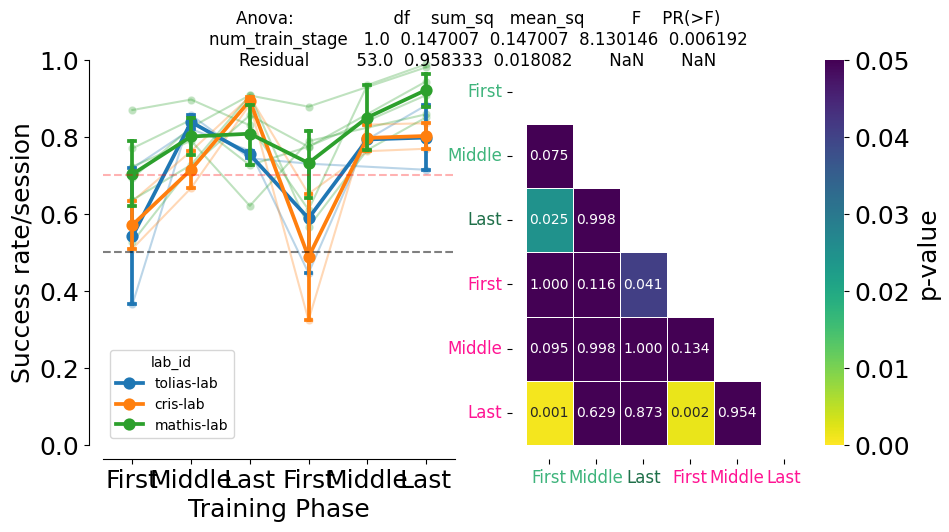

In [7]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
plotting.plot_training_phases(ax[0], data=session_df, y="session_reward", ylabel="Success rate/session", ylim=(0,1), hue="lab_id")

anova_rewarded = ols('session_reward ~ num_train_stage',
             data=session_df).fit()
table = sm.stats.anova_lm(anova_rewarded, typ=1)
print("Anova")
print(table)
print("TuckeyHSD")
results = sm.stats.multicomp.pairwise_tukeyhsd(session_df.session_reward, session_df.num_train_stage, alpha=0.05)
results.summary()
fig.suptitle(f"Anova:{table}")

sns.despine(offset=10)

# Plot heatmap
plot_training_stats_heatmap(ax [1], results)
plt.savefig(save_fig_path + "figure_1_training_success_rate.svg", transparent=True)

2025-07-01 16:33:11,378::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:33:11,378::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:33:11,385::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2025-07-01 16:33:11,385::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Anova
                   df      sum_sq     mean_sq         F    PR(>F)
num_train_stage   1.0  138.855866  138.855866  8.328483  0.005634
Residual         53.0  883.637602   16.672408       NaN       NaN
TuckeyHSD


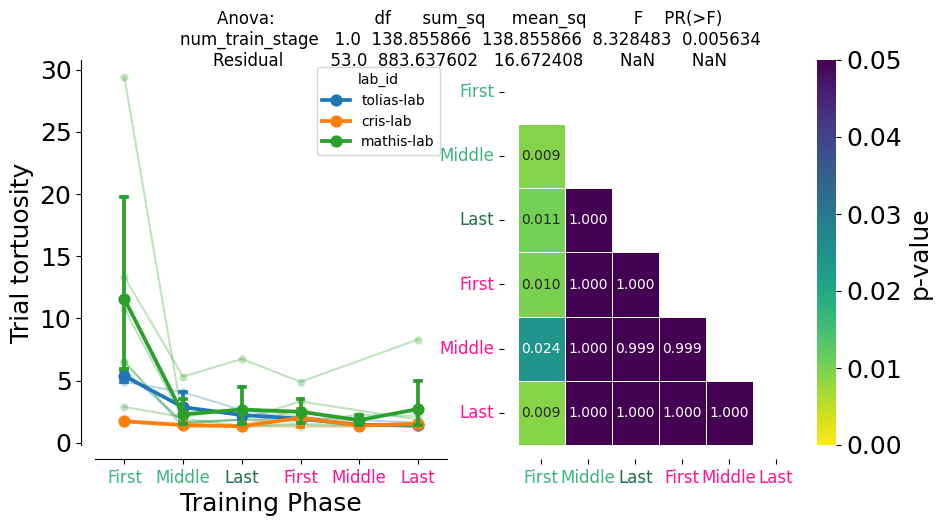

In [8]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
plotting.plot_training_phases(ax[0], data=session_df, y="session_tortuosity", ylabel="Trial tortuosity", hue="lab_id")

anova_rewarded = ols('session_tortuosity ~ num_train_stage',
             data=session_df).fit()
table = sm.stats.anova_lm(anova_rewarded, typ=1)
print("Anova")
print(table)
print("TuckeyHSD")
results = sm.stats.multicomp.pairwise_tukeyhsd(session_df.session_tortuosity, session_df.num_train_stage, alpha=0.05)
results.summary()
plot_training_stats_heatmap(ax [1], results)
fig.suptitle(f"Anova:{table}")

plt.savefig(save_fig_path + "figure_1_training_tortuosity.svg", transparent=True)

2025-07-01 16:33:12,606::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:33:12,606::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:33:12,616::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:33:12,616::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Anova
                   df       sum_sq     mean_sq          F    PR(>F)
num_train_stage   1.0   773.058815  773.058815  11.271117  0.001463
Residual         53.0  3635.142448   68.587593        NaN       NaN
TuckeyHSD


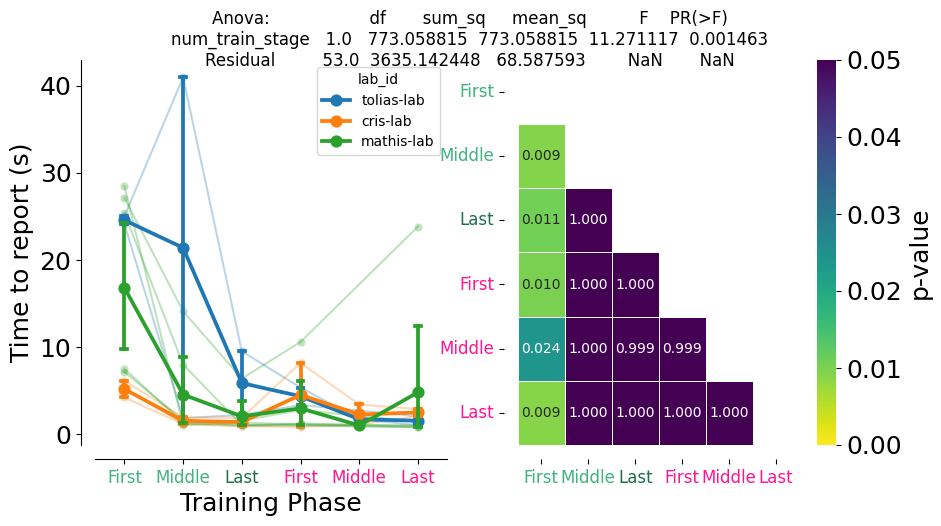

In [9]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
plotting.plot_training_phases(ax[0], data=session_df, y="session_trial_duration", ylabel="Time to report (s)", hue="lab_id")

anova_rewarded = ols('session_trial_duration ~ num_train_stage',
             data=session_df).fit()
table = sm.stats.anova_lm(anova_rewarded, typ=1)
print("Anova")
print(table)
print("TuckeyHSD")
results = sm.stats.multicomp.pairwise_tukeyhsd(session_df.session_tortuosity, session_df.num_train_stage, alpha=0.05)
results.summary()
plot_training_stats_heatmap(ax [1], results)
fig.suptitle(f"Anova:{table}")

plt.savefig(save_fig_path + "figure_1_training_trial_duration.svg", transparent=True)

2025-07-01 16:33:13,802::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:33:13,802::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:33:13,810::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:33:13,810::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


                   df    sum_sq   mean_sq         F    PR(>F)
num_train_stage   1.0  0.003841  0.003841  0.319889  0.574061
Residual         53.0  0.636345  0.012007       NaN       NaN
TuckeyHSD


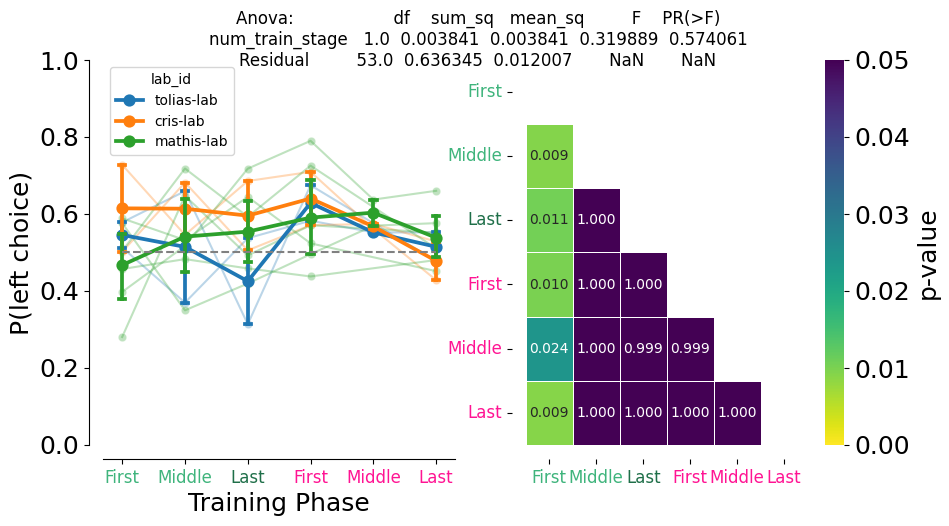

In [10]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
plotting.plot_training_phases(ax[0], data=session_df, y="session_bias", ylabel="P(left choice)", ylim=(0,1), hue="lab_id")

anova_rewarded = ols('session_bias ~ num_train_stage',
             data=session_df).fit()
table = sm.stats.anova_lm(anova_rewarded, typ=1)
print(table)

ax[0].hlines(0.5, xmin=0, xmax=session_df.num_train_stage.max(), color="grey", linestyle="--")

print("TuckeyHSD")
results = sm.stats.multicomp.pairwise_tukeyhsd(session_df.session_tortuosity, session_df.num_train_stage, alpha=0.05)
results.summary()
plot_training_stats_heatmap(ax[1], results)
fig.suptitle(f"Anova:{table}")

fig.suptitle(f"Anova:{table}")
plt.savefig(save_fig_path + "figure_1_training_bais.svg", transparent=True)

2025-07-01 16:33:14,937::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:33:14,937::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:33:14,944::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:33:14,944::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


                   df         sum_sq       mean_sq          F    PR(>F)
num_train_stage   1.0   88504.064246  88504.064246  22.752666  0.000015
Residual         53.0  206161.135754   3889.832750        NaN       NaN
Anova


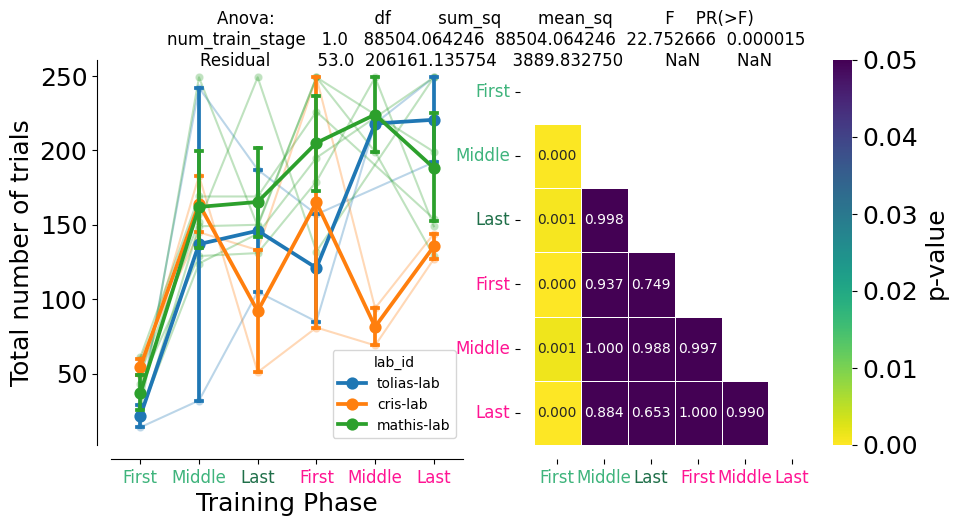

In [11]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
plotting.plot_training_phases(ax[0], data=session_df, y="session_max_trial_number", ylabel="Total number of trials", hue="lab_id")

anova_rewarded = ols('session_max_trial_number ~ num_train_stage',
             data=session_df).fit()
table = sm.stats.anova_lm(anova_rewarded, typ=1)
print(table)
print("Anova")
results = sm.stats.multicomp.pairwise_tukeyhsd(session_df.session_max_trial_number, session_df.num_train_stage, alpha=0.05)
results.summary()
plot_training_stats_heatmap(ax [1], results)
fig.suptitle(f"Anova:{table}")

plt.savefig(save_fig_path + "figure_1_training_max_trial_number.svg", transparent=True)

2025-07-01 16:33:16,133::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:33:16,133::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:33:16,141::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:33:16,141::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


                   df    sum_sq   mean_sq          F    PR(>F)
num_train_stage   1.0  1.238463  1.238463  29.529584  0.000001
Residual         53.0  2.222806  0.041940        NaN       NaN
Anova


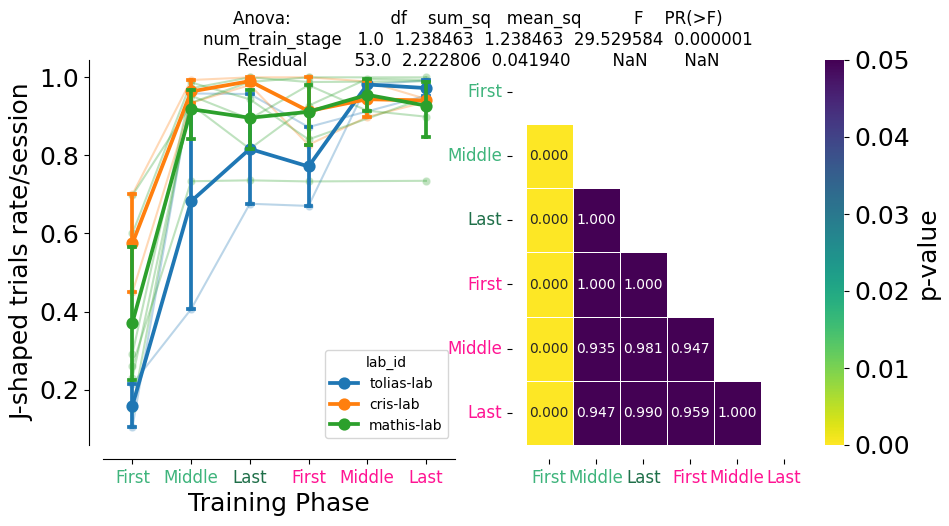

In [12]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
plotting.plot_training_phases(ax[0], data=session_df, y="session_jshaped", ylabel="J-shaped trials rate/session", hue="lab_id")
anova_rewarded = ols('session_jshaped ~ num_train_stage',
             data=session_df).fit()
table = sm.stats.anova_lm(anova_rewarded, typ=1)
print(table)
print("Anova")

results = sm.stats.multicomp.pairwise_tukeyhsd(session_df.session_jshaped, session_df.num_train_stage, alpha=0.05)
results.summary()
plot_training_stats_heatmap(ax [1], results)
fig.suptitle(f"Anova:{table}")

plt.savefig(save_fig_path + "figure_1_training_jshaped.svg", transparent=True)


# Just checking the strange looking mouse

Text(0.5, 1.0, 'Nightingale')

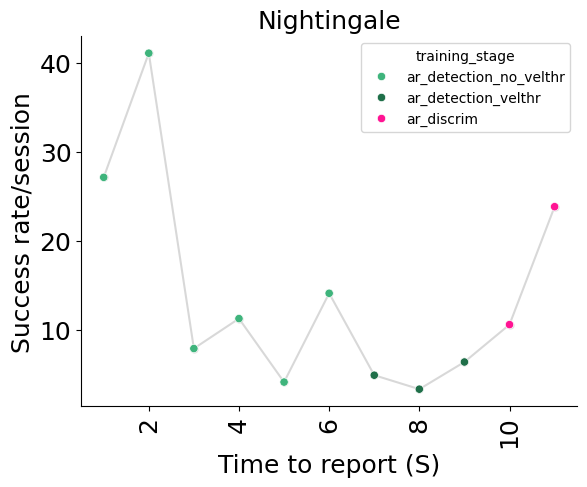

In [13]:
Nightingale  =big_df [big_df.mouse_name == "Nightingale"]
sns.lineplot(data = Nightingale, x="session_increment", y="session_trial_duration", units="mouse_name", estimator=None, marker="o", color="grey", zorder=0, alpha=.3)
sns.scatterplot(data = Nightingale, x="session_increment", y="session_trial_duration", hue="training_stage", palette=["#3FB47C",  "#1F6F49", "#FF1493"], zorder=10)
plt.xticks(rotation = 90)
plt.xlabel("Time to report (S)")
plt.ylabel("Success rate/session")
plt.title(f"{Nightingale.mouse_name.iloc[0]}")
#plt.ylim(0,1)

# Plotting by lab

In [14]:
session_df["lab_id"].unique()

array(['tolias-lab', 'cris-lab', 'mathis-lab'], dtype=object)

2025-07-01 16:33:17,551::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:33:17,551::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:33:17,559::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:33:17,559::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


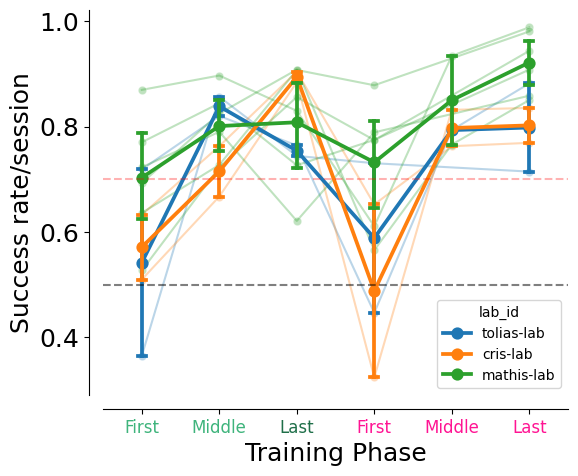

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(6,5))
plotting.plot_training_phases(ax, data=session_df, y="session_reward", ylabel="Success rate/session",hue="lab_id")

plt.savefig(save_fig_path + "figure_1_training_by_labs_session_reward.svg", transparent=True)

2025-07-01 16:33:18,188::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:33:18,188::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:33:18,196::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:33:18,196::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Axes: xlabel='Training Phase', ylabel='Trial tortuosity'>

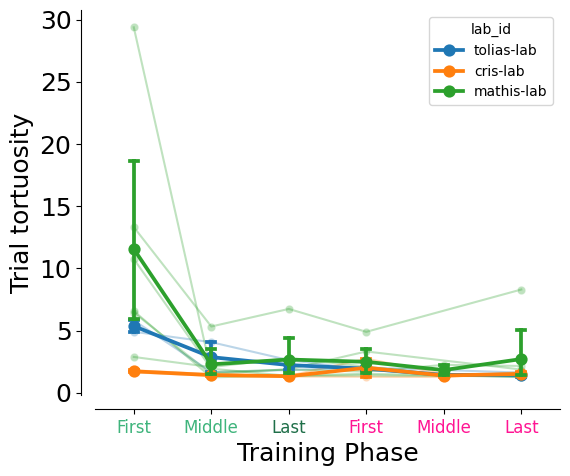

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(6,5))
plotting.plot_training_phases(ax, data=session_df, y="session_tortuosity", ylabel="Trial tortuosity",hue="lab_id")

2025-07-01 16:33:18,762::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:33:18,762::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:33:18,770::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:33:18,770::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Axes: xlabel='Training Phase', ylabel='Trial number'>

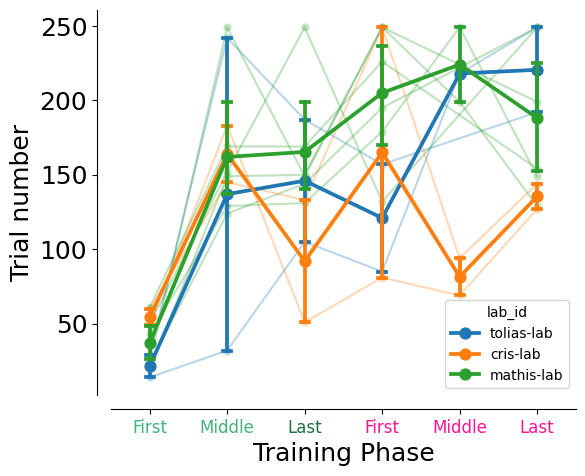

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(6,5))
plotting.plot_training_phases(ax, data=session_df, y="session_max_trial_number", ylabel="Trial number",hue="lab_id")

2025-07-01 16:33:19,494::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:33:19,494::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:33:19,513::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:33:19,513::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Axes: xlabel='Training Phase', ylabel='Time to report (s)'>

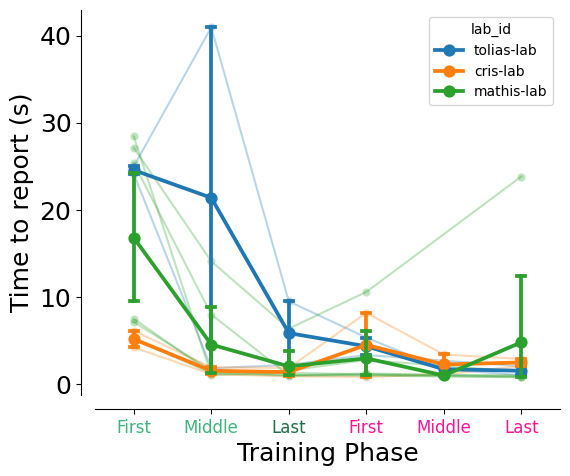

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(6,5))
plotting.plot_training_phases(ax, data=session_df, y="session_trial_duration", ylabel="Time to report (s)",hue="lab_id")


2025-07-01 16:44:37,019::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:44:37,019::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:44:37,037::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:44:37,037::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 16:44:37,396::INFO::category.py::Using categorical un

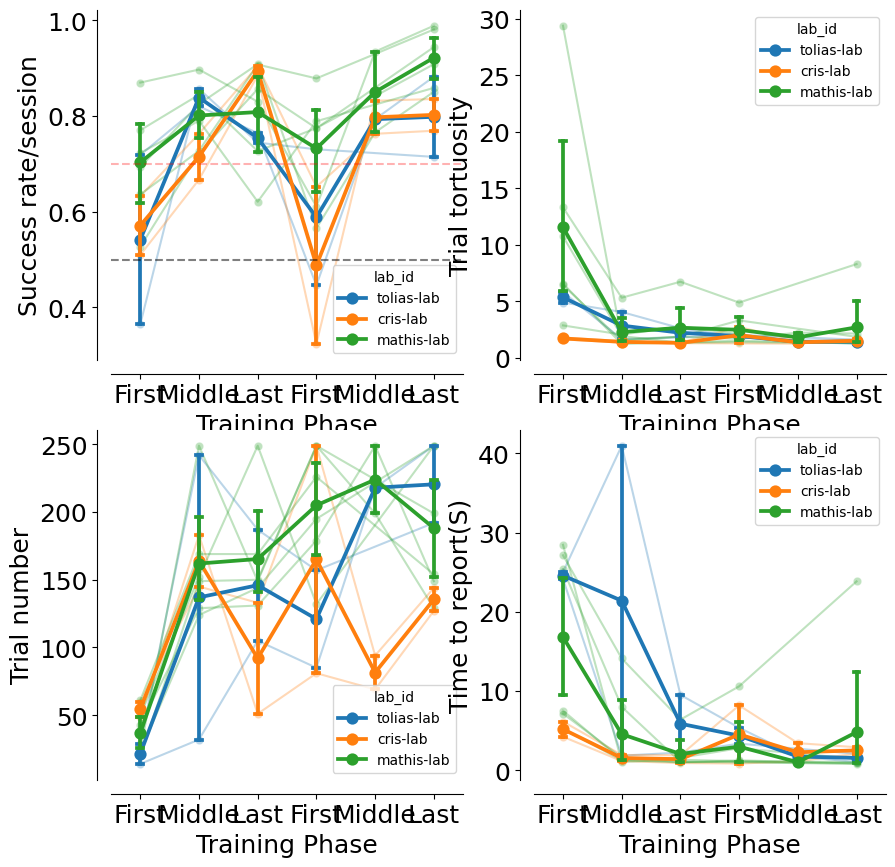

In [23]:
fig, ax = plt.subplots(2,2, figsize=(10,10))
plotting.plot_training_phases(ax[0,0], data=session_df, y="session_reward", ylabel="Success rate/session",hue="lab_id")
plotting.plot_training_phases(ax[0,1], data=session_df, y="session_tortuosity", ylabel="Trial tortuosity",hue="lab_id")
plotting.plot_training_phases(ax[1,0], data=session_df, y="session_max_trial_number", ylabel="Trial number",hue="lab_id")
plotting.plot_training_phases(ax[1,1], data=session_df, y="session_trial_duration", ylabel="Time to report(S)",hue="lab_id")

sns.despine(offset=10)
plt.savefig(save_fig_path + "figure_1_training_by_labs.svg", transparent=True)

In [20]:
training_days = big_df.groupby(["mouse_name"], as_index=False)["dataset"].nunique()
training_days["trials"] = big_df.groupby(["mouse_name"], as_index=False)["session_max_trial_number"].sum()["session_max_trial_number"]

In [31]:
training_days.mean(), training_days.sem()

(dataset      13.4
 trials     1644.0
 dtype: float64,
 dataset      1.758787
 trials     143.573984
 dtype: float64)

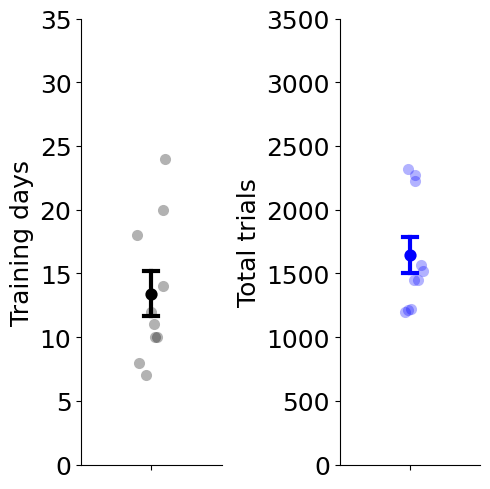

In [21]:
fig, ax = plt.subplots(1,2,figsize=(5,5))
sns.stripplot(
    data=training_days,
    y="dataset",
    color="black",
    jitter=True,
    size=8,
    alpha=0.3,
    zorder=0,
    ax=ax[0]
)

sns.pointplot(
    data=training_days,
    y="dataset",
    join=False,
    color="black",
    markers="o",
    errorbar="se",
    capsize=0.1,
    errwidth=3,
    zorder=2,
    ax=ax[0]
)

 
ax[0].set_ylim(0,35)
ax[0].set_ylabel("Training days")

sns.stripplot(
    data=training_days,
    y="trials",
    color="blue",
    jitter=True,
    size=8,
    alpha=0.3,
    zorder=0,
    ax=ax[1]
)
sns.pointplot(
    data=training_days,
    y="trials",
    join=False,
    color="blue",
    markers="o",
    errorbar="se",
    capsize=0.1,
    errwidth=3,
    zorder=2,
    ax=ax[1]
)

ax[1].set_ylim(0,3500)
ax[1].set_ylabel("Total trials")
plt.tight_layout()
plt.savefig(save_fig_path + "figure_1_training_days_and_trials.svg", transparent=True)

# Every thing below this is old code, for my own reference ..... Ignore

In [22]:
dfs = []
for stage in ["ar_detection_no_velthr", "ar_detection_velthr", "ar_discrim"]:
    training = (vr4mice.Dataset() & f'session_label = "{stage}" AND dataset LIKE "%31726%"') & (
        vr4mice.Collab() & "idx=2"
    ) 
    training_list = [{"dataset": x["dataset"]} for x in training]
    if {"dataset": "Nightingale_2024-07-31_1"} in training_list:  # mathis lab
        training_list.remove({"dataset": "Nightingale_2024-07-31_1"})
    if {"dataset": "tom_2024-11-01_1"} in training_list:  # tolias lab
        training_list.remove({"dataset": "tom_2024-11-01_1"})
    dfs.append(get_all_in_list(data_set_list=training_list, training_stage=stage))
    
for stage in ["ar_detection_no_velthr", "ar_detection_velthr", "ar_discrim"]:
    training = (vr4mice.Dataset() & f'session_label = "{stage}" AND dataset LIKE "%31728%"') & (
        vr4mice.Collab() & "idx=2"
    ) 
    training_list = [{"dataset": x["dataset"]} for x in training]
    if {"dataset": "Nightingale_2024-07-31_1"} in training_list:  # mathis lab
        training_list.remove({"dataset": "Nightingale_2024-07-31_1"})
    if {"dataset": "tom_2024-11-01_1"} in training_list:  # tolias lab
        training_list.remove({"dataset": "tom_2024-11-01_1"})
    dfs.append(get_all_in_list(data_set_list=training_list, training_stage=stage))

NameError: name 'get_all_in_list' is not defined

In [ ]:
dfs = []
for stage in ["ar_detection_no_velthr", "ar_detection_velthr", "ar_discrim"]:
    training = (vr4mice.Dataset() & f'session_label = "{stage}"') & (
        vr4mice.Collab() & "idx=3"
    )
    training_list = [{"dataset": x["dataset"]} for x in training]
    if {"dataset": "Nightingale_2024-07-31_1"} in training_list:  # mathis lab
        training_list.remove({"dataset": "Nightingale_2024-07-31_1"})
    if {"dataset": "tom_2024-11-01_1"} in training_list:  # tolias lab
        training_list.remove({"dataset": "tom_2024-11-01_1"})
    dfs.append(get_all_in_list(data_set_list=training_list, training_stage=stage))

big_df = pd.concat(dfs).reset_index(drop=True)

In [ ]:
big_df = pd.concat(dfs).reset_index(drop=True)
big_df.to_pickle("big_df_contrast_training_tolias.pkl")

In [ ]:
big_df.to_pickle("big_df_contrast_training_niell.pkl")

In [ ]:
niell_data = pd.read_pickle("big_df_contrast_training_niell.pkl")
mathis_data = pd.read_pickle("big_df_contrast_training_mathis.pkl")
tolias_data = pd.read_pickle("big_df_contrast_training_tolias.pkl")

big_df = pd.concat([niell_data, mathis_data, tolias_data]).reset_index(drop=True)

In [ ]:
big_df = big_df[big_df.mouse_name != "Vegavis"]
big_df = big_df[big_df.dataset != "Nightingale_2024-07-31_2"]
big_df = big_df[big_df.dataset != "Kiwi_2024-08-08_3"]

In [ ]:



def training_plots(
    big_df,
    mouse_name,
    variable,
    ax,
    ylim=(0, 1),
    midpoint_line=True,
    criterion_line=True,
    ylabel="Success rate/session",
    xlabel="Session",
    cmap=["#3FB47C", "#1F6F49", "#FF1493"],
    s=70,
):

    big_df = big_df.copy()
    big_df = big_df[big_df.mouse_name == mouse_name].copy()
    mean_mouse = big_df.groupby(
        ["mouse_name", "training_stage", "num_train_stage", "trial"], as_index=False
    ).mean(numeric_only=True)
    data = mean_mouse.groupby(
        ["mouse_name", "training_stage", "num_train_stage"], as_index=False
    ).mean(numeric_only=True)
    #print(mean_mouse [["mouse_name", "training_stage", "num_train_stage", "trial_duration"]])
    #data = mean_mouse[mean_mouse.mouse_name == mouse_name].copy()
    sns.lineplot(
        data=data,
        x="num_train_stage",
        y=variable,
        color="grey",
        legend=None,
        alpha=0.4,
        ax=ax,
        linewidth=1,
    )
    sns.scatterplot(
        data=data,
        x="num_train_stage",
        y=variable,
        hue="training_stage",
        palette=cmap,
        alpha=0.9,
        legend=None,
        zorder=100,
        s=s,
        ax=ax,
    )

    if variable == "trial_rewarded":
        ax.set_ylim(ylim[0], ylim[1])
        if midpoint_line:
            ax.axhline(0.5, linestyle="dashed", color="black", alpha=0.5)
        if criterion_line:
            ax.axhline(0.70, linestyle="dashed", color="red", alpha=0.3)
    if variable == "trial_count":
        ax.axhline(125, linestyle="dashed", color="red", alpha=0.3)

    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    sns.despine(offset=10)
    return(data)


def days_in_training_stage(big_df, mouse_name):
    mean_mouse = big_df[big_df.mouse_name == mouse_name]
    mean_mouse = mean_mouse.groupby(["training_stage"], as_index=False)[
        "session"
    ].nunique()
    return mean_mouse

## Training task performance & training time

In [ ]:
big_df = big_df[big_df.mouse_name != "Vegavis"]
big_df = big_df[big_df.dataset != "Nightingale_2024-07-31_2"]
big_df = big_df[big_df.dataset != "Kiwi_2024-08-08_3"]
big_df["session_increment"] = (
    big_df.groupby("mouse_name")["dataset"]
    .rank(method="dense", ascending=True)
    .astype(int)
)

# Mean plots

In [ ]:
combined_training_df = []
for mouse_name in big_df.mouse_name.unique():
   tmp_df = get_training_stage_per_mouse(big_df, mouse_name)
   combined_training_df.append(tmp_df)

In [ ]:
mean_mouse = pd.concat(combined_training_df).groupby(
        ["mouse_name", "training_stage", "num_train_stage", "trial"], as_index=False
    ).mean(numeric_only=True)
mean_mouse = mean_mouse.groupby(
        ["mouse_name", "training_stage", "num_train_stage"], as_index=False
    ).mean(numeric_only=True)

In [ ]:
session_df = mean_mouse[["mouse_name", "training_stage", "num_train_stage", "trial", "trial_rewarded", "trial_duration"]]

2025-05-07 08:37:49,140::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-07 08:37:49,140::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-07 08:37:49,149::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-07 08:37:49,149::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


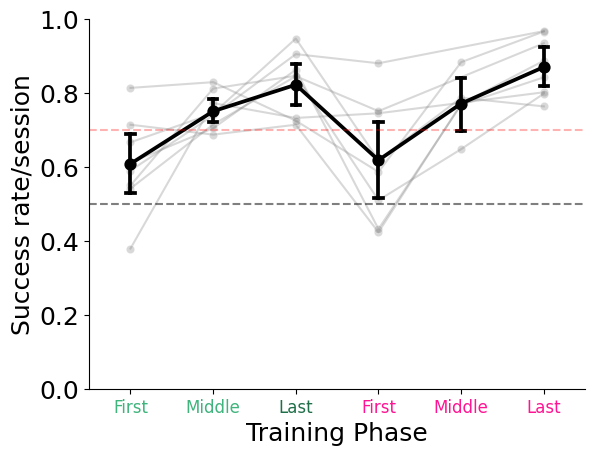

In [ ]:
fig, ax = plt.subplots(1,1)
sns.lineplot(data = session_df, x="num_train_stage", y="trial_rewarded", units="mouse_name", estimator=None, marker="o", color="grey", zorder=0, alpha=.3)
sns.pointplot(data = session_df, x="num_train_stage", y="trial_rewarded", color="black", capsize=0.1)

ax.set_xlabel("Training Phase")
ax.set_ylabel("Success rate/session")
ax.set_ylim(0,1)
for i in range(1):
    # Define tick positions and labels
    stage_positions = np.arange(6)  # Adjust if needed
    stage_labels = ["First", "Middle", "Last", "First", "Middle", "Last"]
    stage_colors = ["#3FB47C", "#3FB47C", "#1F6F49", "#FF1493", "#FF1493", "#FF1493"]

    ax.set_xticks(stage_positions)
    ax.set_xticklabels(stage_labels, rotation=0, fontsize=12)
    ax.axhline(0.5, linestyle="dashed", color="black", alpha=0.5)
    ax.axhline(0.70, linestyle="dashed", color="red", alpha=0.3)
    

    for j, label in enumerate(ax.get_xticklabels()):
        label.set_color(stage_colors[j])

2025-05-07 08:37:49,807::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-07 08:37:49,807::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-07 08:37:49,816::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-07 08:37:49,816::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


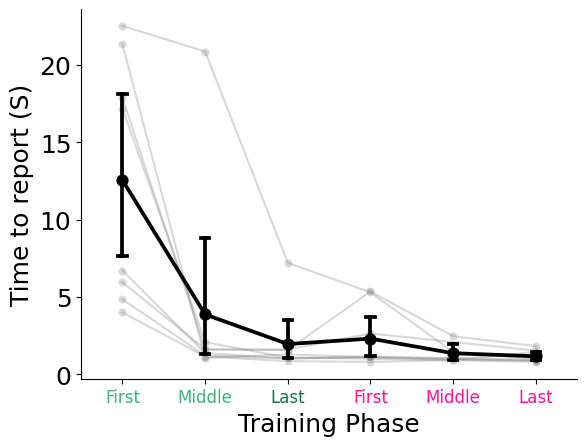

In [ ]:
fig, ax = plt.subplots(1,1)
sns.lineplot(data = session_df, x="num_train_stage", y="trial_duration", units="mouse_name", estimator=None, marker="o", color="grey", zorder=0, alpha=.3)
sns.pointplot(data = session_df, x="num_train_stage", y="trial_duration", color="black", capsize=0.1)

ax.set_xlabel("Training Phase")
ax.set_ylabel("Time to report (S)")
for i in range(2):
    # Define tick positions and labels
    stage_positions = np.arange(6)  # Adjust if needed
    stage_labels = ["First", "Middle", "Last", "First", "Middle", "Last"]
    stage_colors = ["#3FB47C", "#3FB47C", "#1F6F49", "#FF1493", "#FF1493", "#FF1493"]

    ax.set_xticks(stage_positions)
    ax.set_xticklabels(stage_labels, rotation=0, fontsize=12)

    

    for j, label in enumerate(ax.get_xticklabels()):
        label.set_color(stage_colors[j])

# stats
Groups are unequal in number therefore use an Anova with Tuckey-HSD

                   df    sum_sq   mean_sq         F   PR(>F)
num_train_stage   1.0  0.135800  0.135800  6.441947  0.01485
Residual         43.0  0.906465  0.021081       NaN      NaN
                   df       sum_sq     mean_sq          F    PR(>F)
num_train_stage   1.0   834.722386  834.722386  13.615028  0.000627
Residual         43.0  2636.282778   61.308902        NaN       NaN


group1,group2,meandiff,p-adj,lower,upper,reject
0,1,0.166,0.0788,-0.0117,0.3436,False
0,2,0.231,0.0047,0.0534,0.4087,True
0,3,0.0039,1.0,-0.1738,0.1815,False
0,4,0.1988,0.057,-0.0038,0.4014,False
0,5,0.2517,0.0017,0.0741,0.4294,True
1,2,0.065,0.8796,-0.1126,0.2427,False
1,3,-0.1621,0.0911,-0.3398,0.0155,False
1,4,0.0328,0.9964,-0.1697,0.2354,False
1,5,0.0858,0.6992,-0.0919,0.2634,False
2,3,-0.2272,0.0056,-0.4048,-0.0495,True


In [ ]:
results = sm.stats.multicomp.pairwise_tukeyhsd(session_df.trial_duration, session_df.num_train_stage, alpha=0.05)
results.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
0,1,-8.4807,0.2511,-19.9151,2.9536,False
0,2,-13.3416,0.0141,-24.776,-1.9072,True
0,3,-12.9245,0.0188,-24.3589,-1.4901,True
0,4,-14.0451,0.0283,-27.0823,-1.0079,True
0,5,-14.2415,0.0074,-25.6759,-2.8071,True
1,2,-4.8609,0.7972,-16.2953,6.5735,False
1,3,-4.4437,0.8508,-15.8781,6.9907,False
1,4,-5.5643,0.7946,-18.6015,7.4729,False
1,5,-5.7607,0.6604,-17.1951,5.6737,False
2,3,0.4171,1.0,-11.0173,11.8515,False


## Total training days

mean:  14.125 
sem:  2.1417407806334947


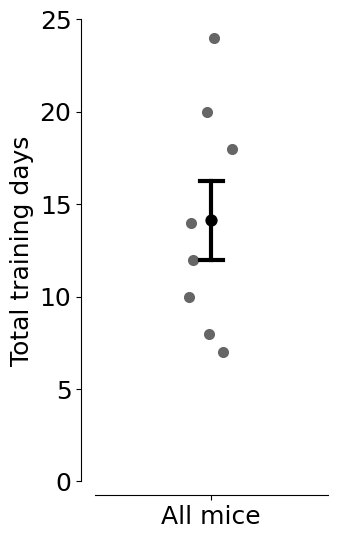

In [ ]:
# Only training days
df = pd.DataFrame(big_df.groupby(["mouse_name"]).session_increment.nunique())
df["group"] = "mice"

plt.figure(figsize=(3, 6))
sns.stripplot(
    x="group",
    y="session_increment",
    data=df,
    color="black",
    jitter=True,
    size=8,
    alpha=0.6,
    zorder=1,
)
sns.pointplot(
    x="group",
    y="session_increment",
    data=df,
    join=False,
    color="black",
    markers="o",
    errorbar="se",
    capsize=0.1,
    errwidth=3,
    zorder=2,
)

plt.xticks([0], ["All mice"])
plt.xlabel("")

plt.ylabel("Total training days")
plt.ylim(0, 25)
sns.despine(offset=10)

plt.savefig(save_fig_path + "figure1_training_days.svg", transparent=True)

print(
    "mean: ",
    df.groupby("group")["session_increment"].mean().values[0],
    "\nsem: ",
    df.groupby("group")["session_increment"].sem().values[0],
)

2025-02-18 10:12:20,083::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-18 10:12:20,083::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-18 10:12:20,091::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-18 10:12:20,091::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-18 10:12:20,125::INFO::category.py::Using categorical un

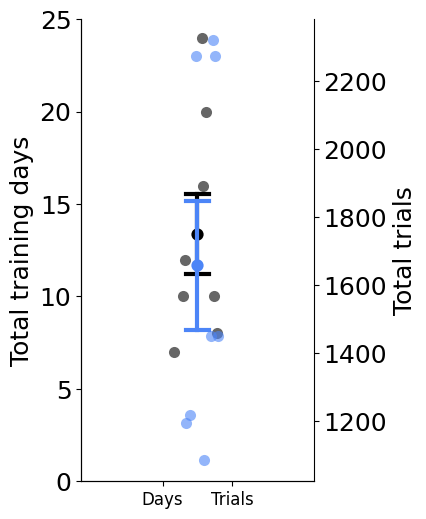

In [ ]:
# Training days and total trials
df = pd.DataFrame(big_df.groupby(["mouse_name"]).session_increment.nunique())
df_trials = pd.DataFrame(
    big_df.groupby(["mouse_name", "dataset"])
    .nunique()
    .groupby("mouse_name")
    .trial.sum()
)

df["group"] = "mice"
df_trials["group"] = "mice"
import numpy as np

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

offset = 0.15

fig, ax1 = plt.subplots(figsize=(3, 6))
sns.stripplot(
    x=np.full(len(df), -offset),
    y="session_increment",
    data=df,
    color="black",
    jitter=True,
    size=8,
    alpha=0.6,
    zorder=1,
    ax=ax1,
)

sns.pointplot(
    x=np.full(len(df), -offset),
    y="session_increment",
    data=df,
    join=False,
    color="black",
    markers="o",
    errorbar="se",
    capsize=0.1,
    errwidth=3,
    zorder=2,
    ax=ax1,
)

ax2 = ax1.twinx()
sns.stripplot(
    x=np.full(len(df_trials), offset),
    y="trial",
    data=df_trials,
    color="#4C85F7",
    jitter=True,
    size=8,
    alpha=0.6,
    zorder=3,
    ax=ax2,
)

sns.pointplot(
    x=np.full(len(df_trials), offset),
    y="trial",
    data=df_trials,
    join=False,
    color="#4C85F7",
    markers="o",
    errorbar="se",
    capsize=0.1,
    errwidth=3,
    zorder=4,
    ax=ax2,
)

ax1.set_xticks([-offset, offset])
ax1.set_xticklabels(["Days", "Trials"], fontsize=12)
ax1.set_ylabel("Total training days")
ax1.set_ylim(0, 25)
ax1.spines["right"].set_visible(False)

ax2.set_ylabel("Total trials", color="k")
ax2.tick_params(axis="y", labelcolor="k")
ax2.spines["right"].set_visible(True)

plt.savefig(save_fig_path + "figure1_training_days_and_trials.svg", transparent=True)

In [ ]:
print(
    "mean: ",
    df.groupby("group")["session_increment"].mean().values[0],
    "\nsem: ",
    df.groupby("group")["session_increment"].sem().values[0],
)

print(
    "mean: ",
    df_trials.groupby("group")["trial"].mean().values[0],
    "\nsem: ",
    df_trials.groupby("group")["trial"].sem().values[0],
)

KeyError: 'group'

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
ax = ax.flatten()
combined_training_df = []
for (i, variable), ylabel in zip(
    enumerate(["trial_rewarded", "trial_duration"]),
    ["Success rate/session", "Time to report (s)"],
):
    for mouse_name in big_df.mouse_name.unique():
        tmp_df = get_training_stage_per_mouse(big_df, mouse_name)
        data = training_plots(
            tmp_df, mouse_name=mouse_name, variable=variable, ax=ax[i], ylabel=ylabel
        )
        #print(tmp_df)
        #ax[i].set_ylim(0.0,1)
        combined_training_df.append(data)
    sns.despine(offset=10, ax=ax[i])

for i in range(2):
    # Define tick positions and labels
    stage_positions = np.arange(6)  # Adjust if needed
    stage_labels = ["First", "Middle", "Last", "First", "Middle", "Last"]
    stage_colors = ["#3FB47C", "#3FB47C", "#1F6F49", "#FF1493", "#FF1493", "#FF1493"]

    ax[i].set_xticks(stage_positions)
    ax[i].set_xticklabels(stage_labels, rotation=0, fontsize=12)

    for j, label in enumerate(ax[i].get_xticklabels()):
        label.set_color(stage_colors[j])

    ax[i].figure.canvas.draw()

plt.savefig(save_fig_path + "figure1_training_success_and_time.svg", transparent=True)